
DADOS EXTRAÍDOS DA IMAGEM - DsRed Otsu KDE slice 110

THRESHOLDS OTSU EXTRAÍDOS:
  P60: 28 a.u.
  P65: 32 a.u.
  P70: 38 a.u.
  P75: 43 a.u.
  P80: 48 a.u.
  P85: 52 a.u.
  P90: 58 a.u.
  P95: 68 a.u.
  P99: 78 a.u.

✅ Dados guardados em: dsred_otsu_extracted_data.csv
   Formato: 40 linhas × 10 colunas
   Colunas: ['x', 'P60', 'P65', 'P70', 'P75', 'P80', 'P85', 'P90', 'P95', 'P99']

📊 A gerar figuras...
✅ Figura guardada: dsred_otsu_all_percentiles.png
✅ Figura guardada: dsred_otsu_P90.png
✅ Figura guardada: dsred_otsu_P99.png

✅ CONCLUÍDO!

Ficheiros gerados:
  1. dsred_otsu_extracted_data.csv - Dados KDE
  2. dsred_otsu_all_percentiles.png - Todos os percentis
  3. dsred_otsu_P90.png - Apenas P90
  4. dsred_otsu_P99.png - Apenas P99

💡 Para tese: Recomendo usar P90 ou P99 (bimodalidade clara)



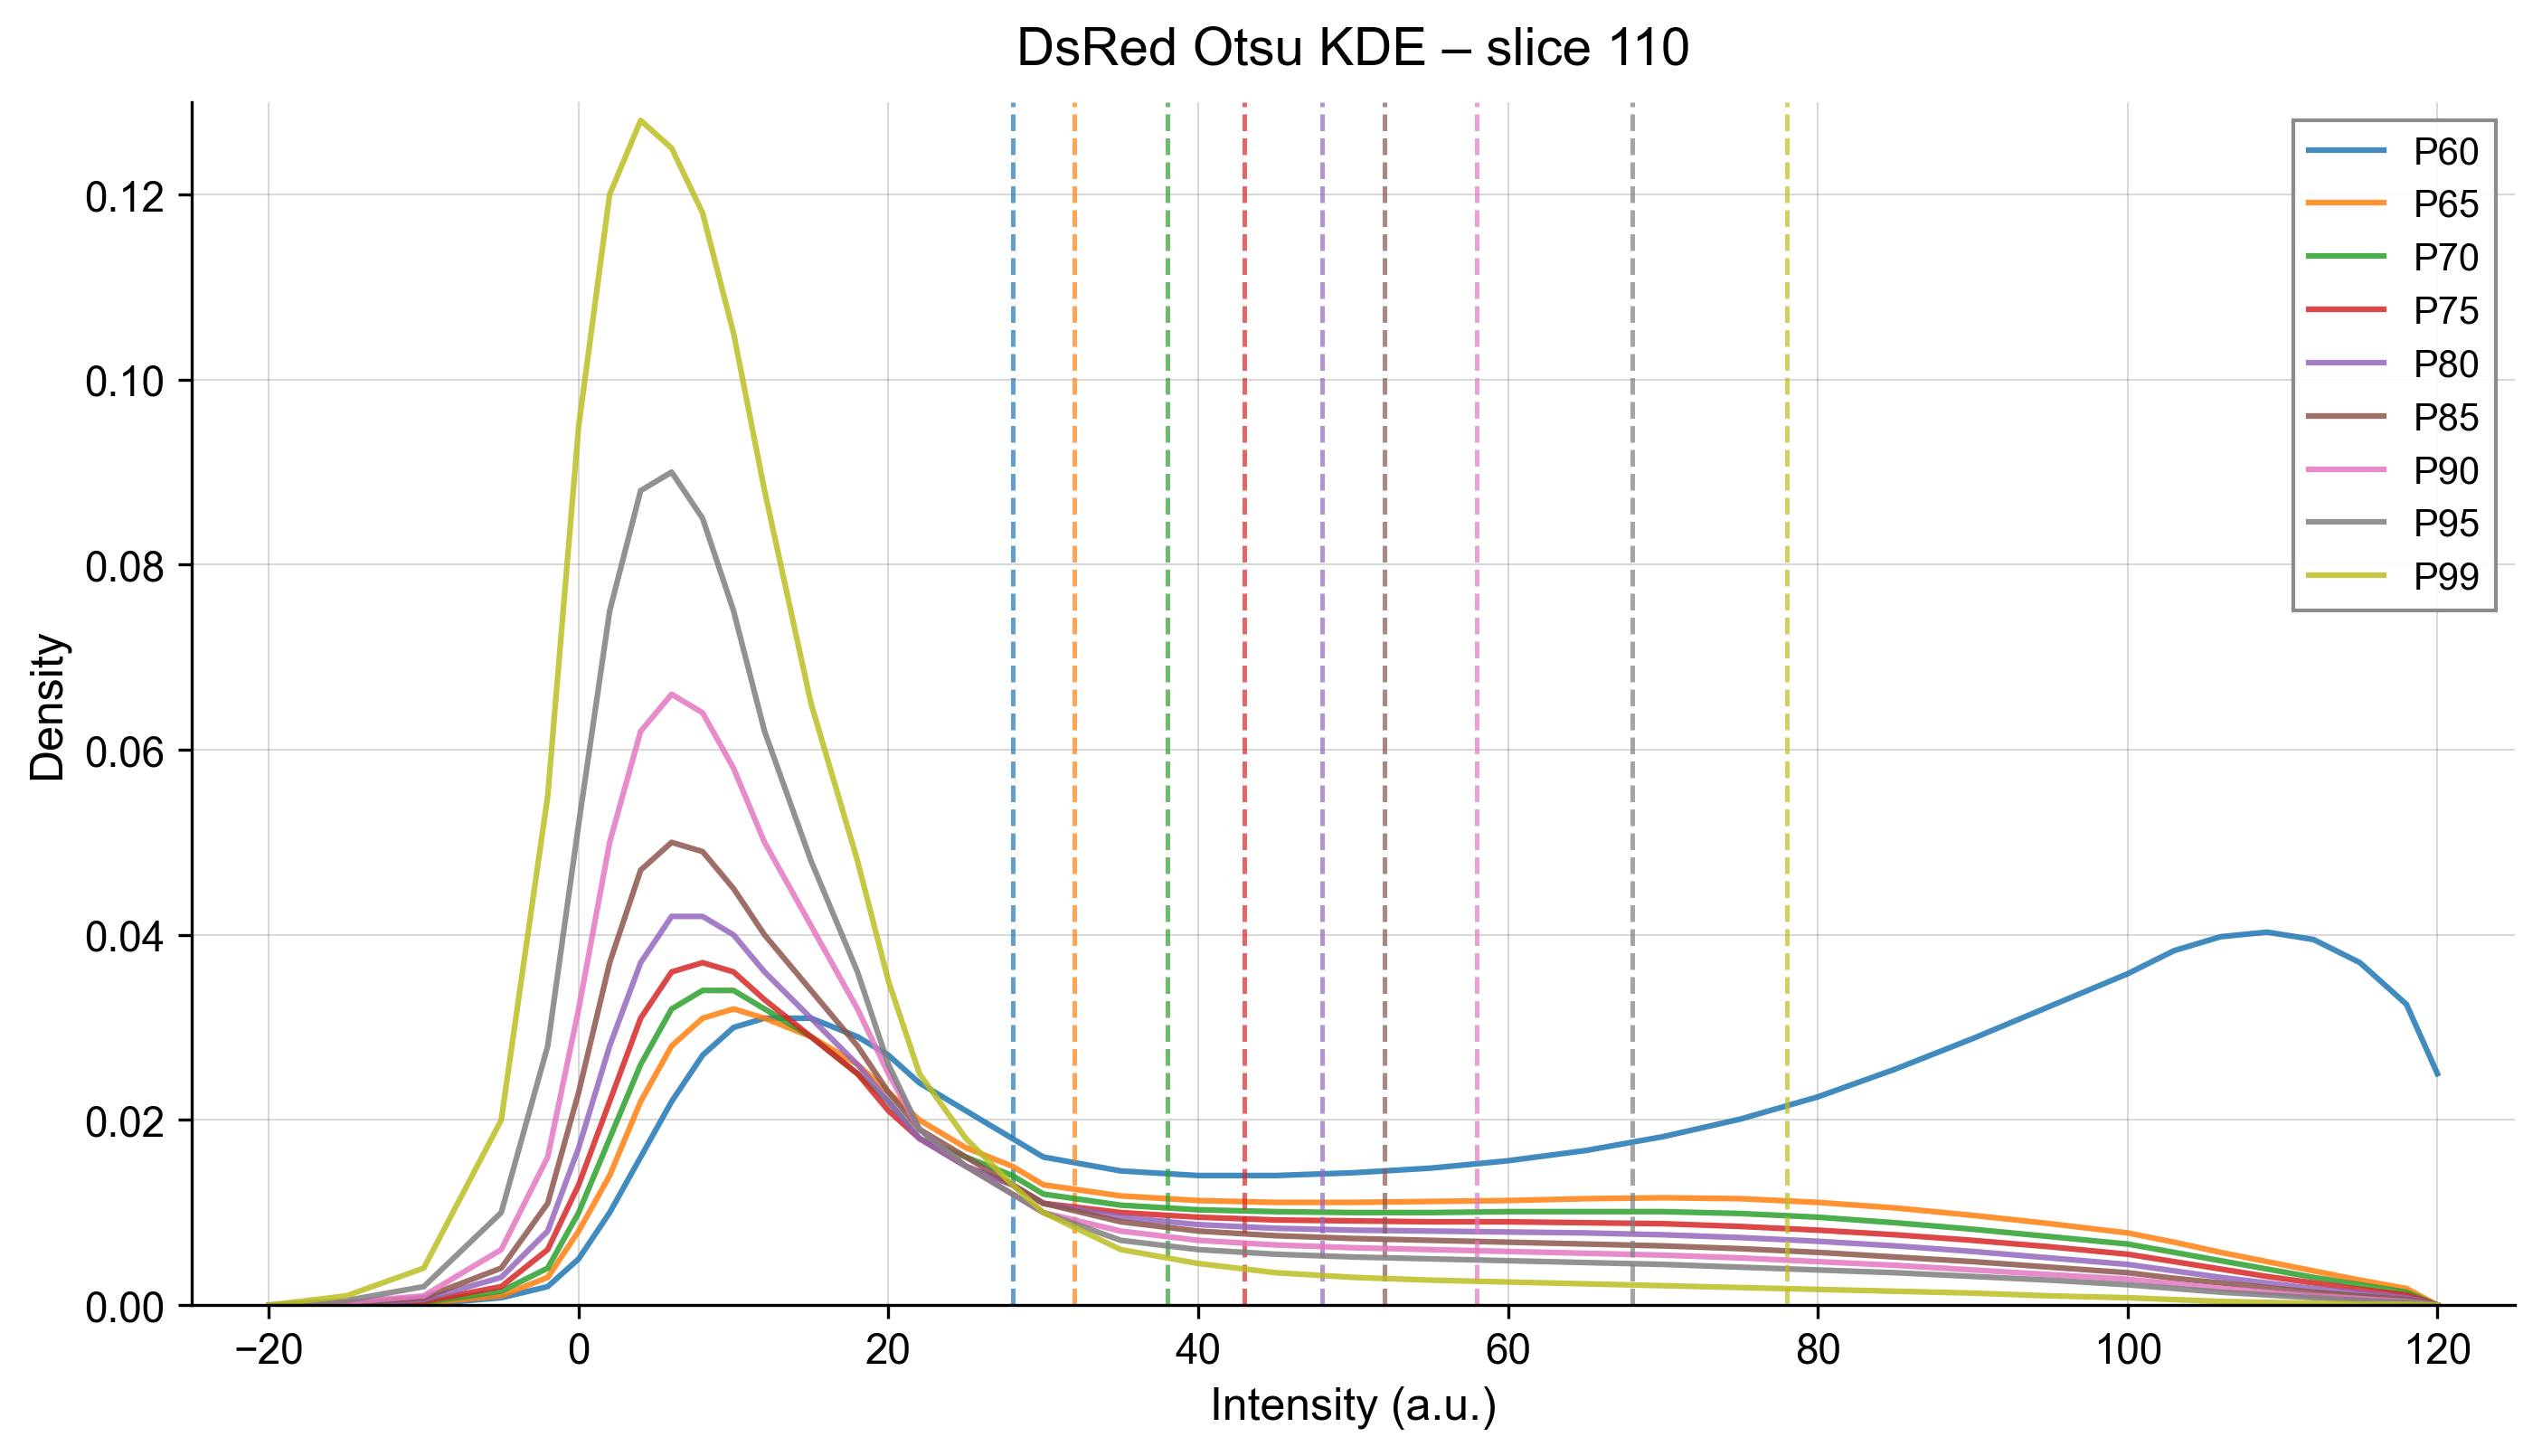

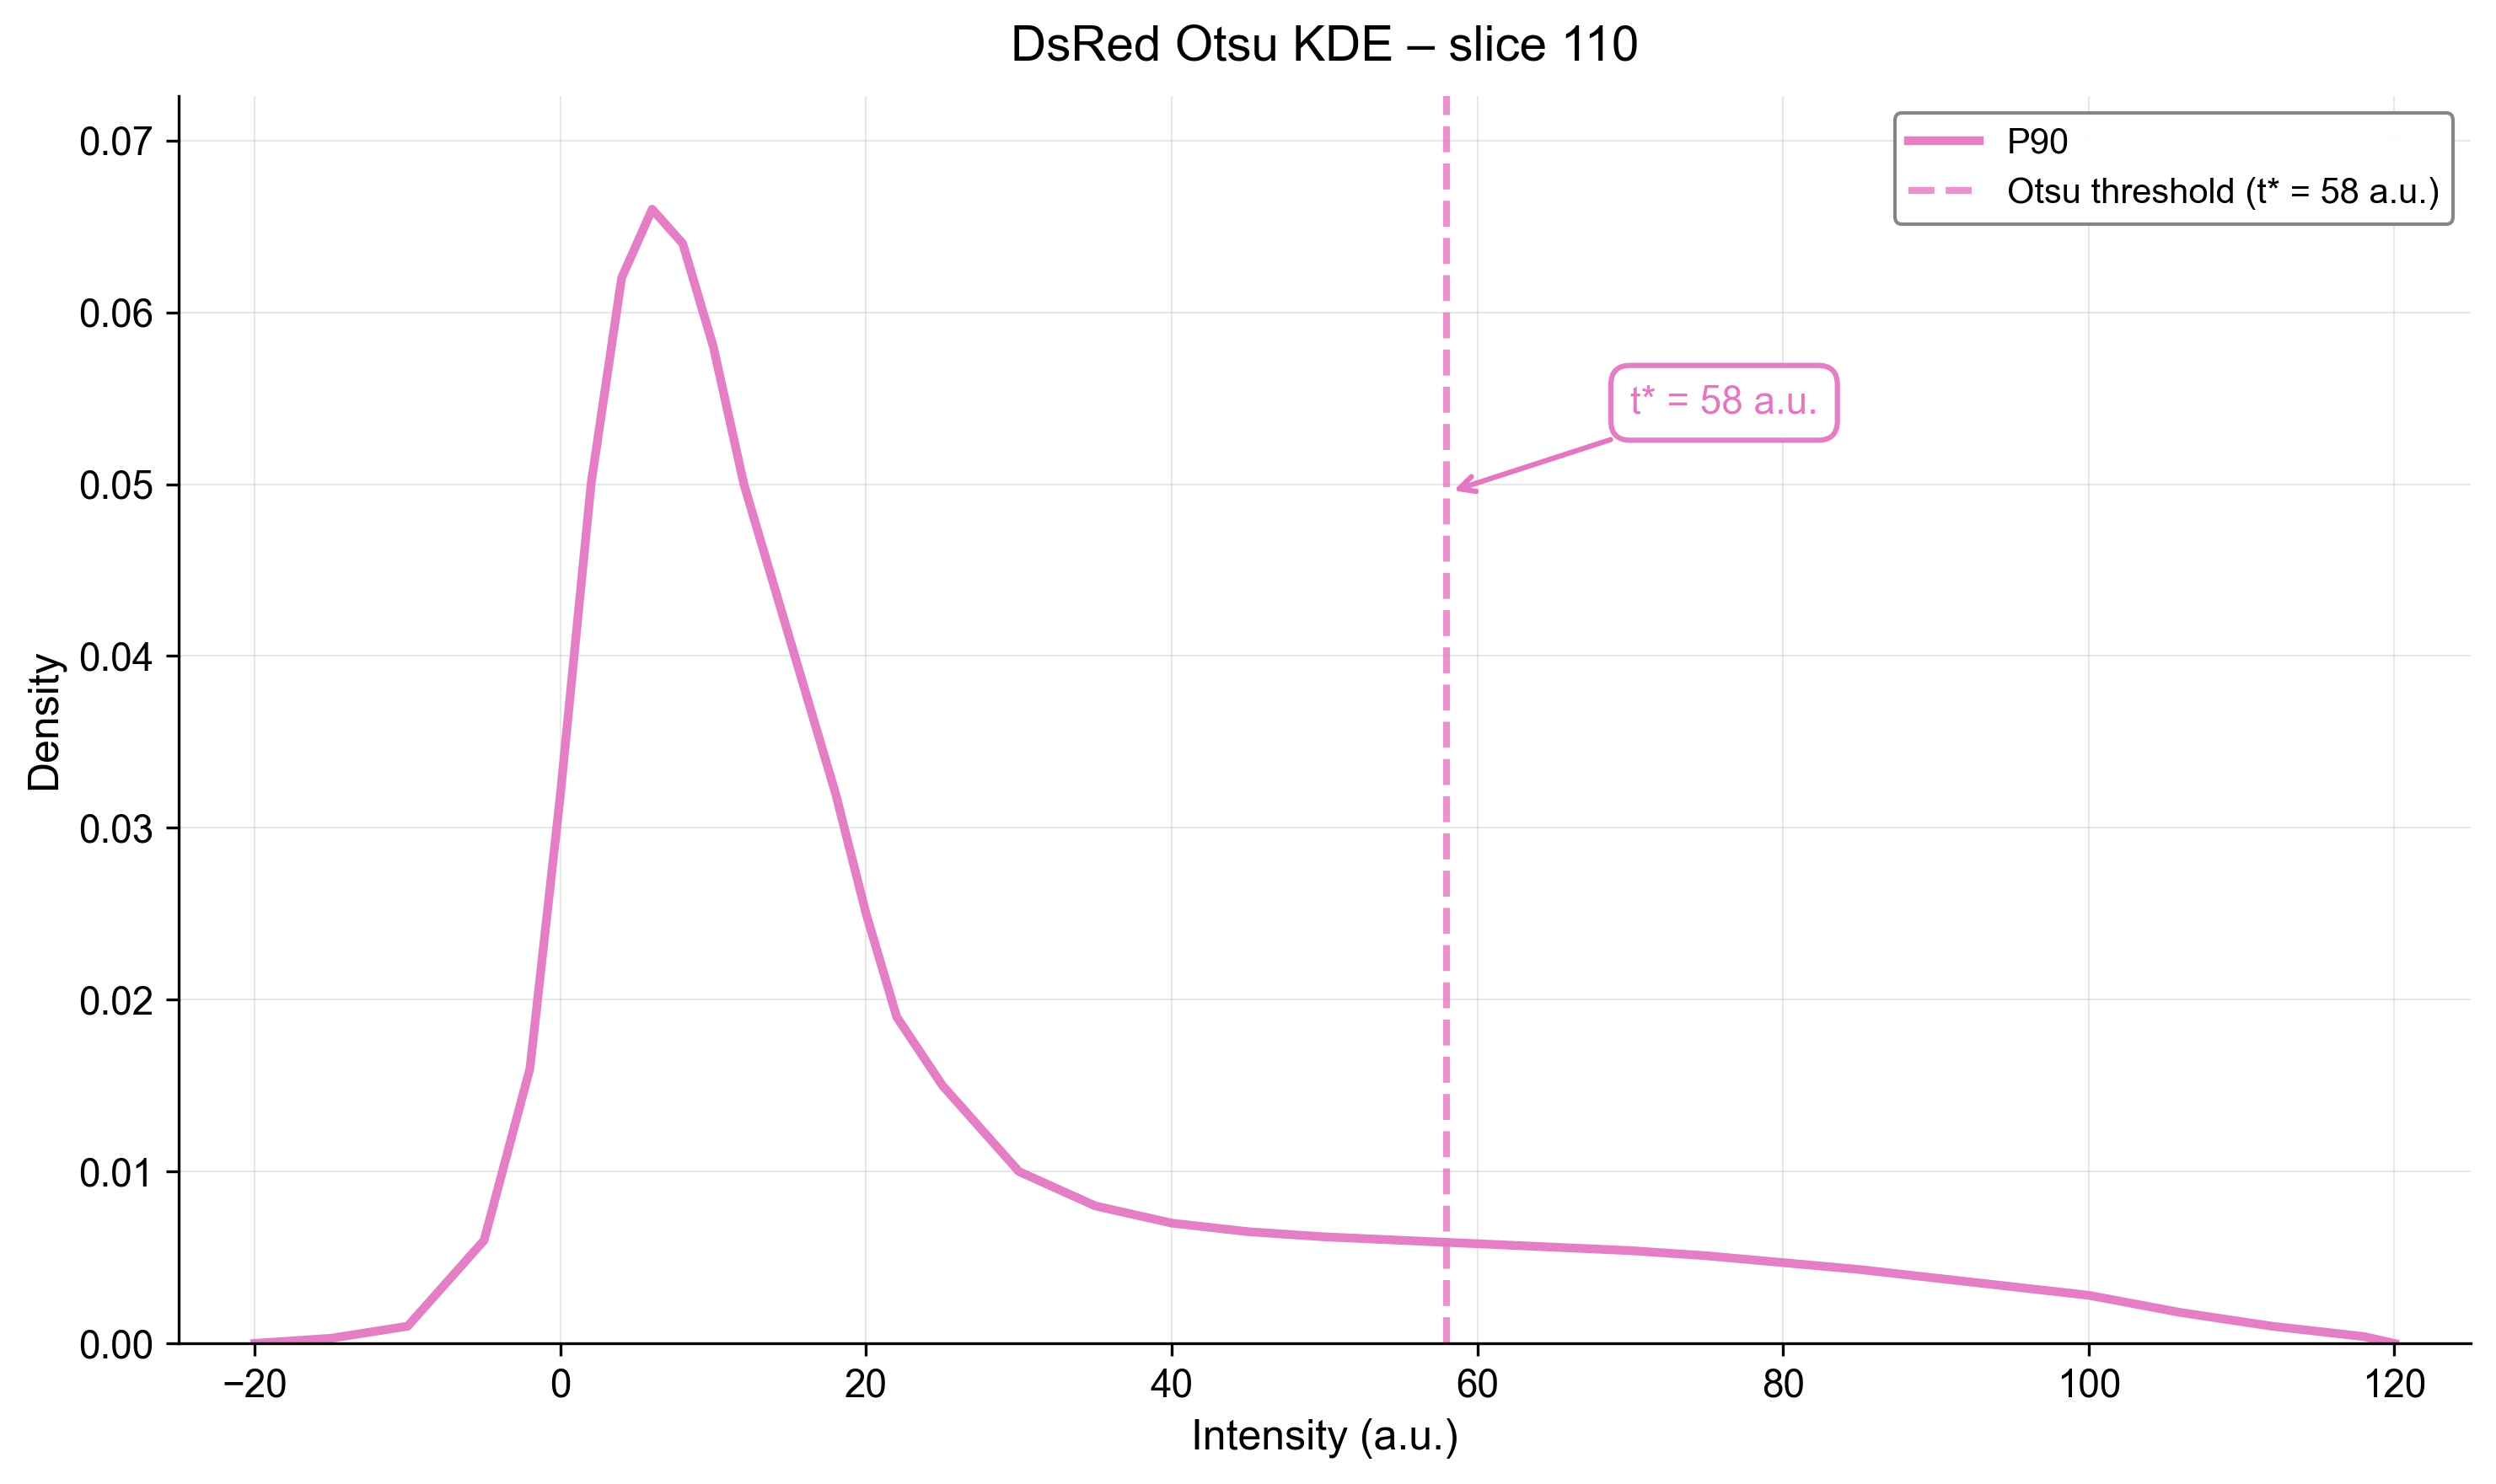

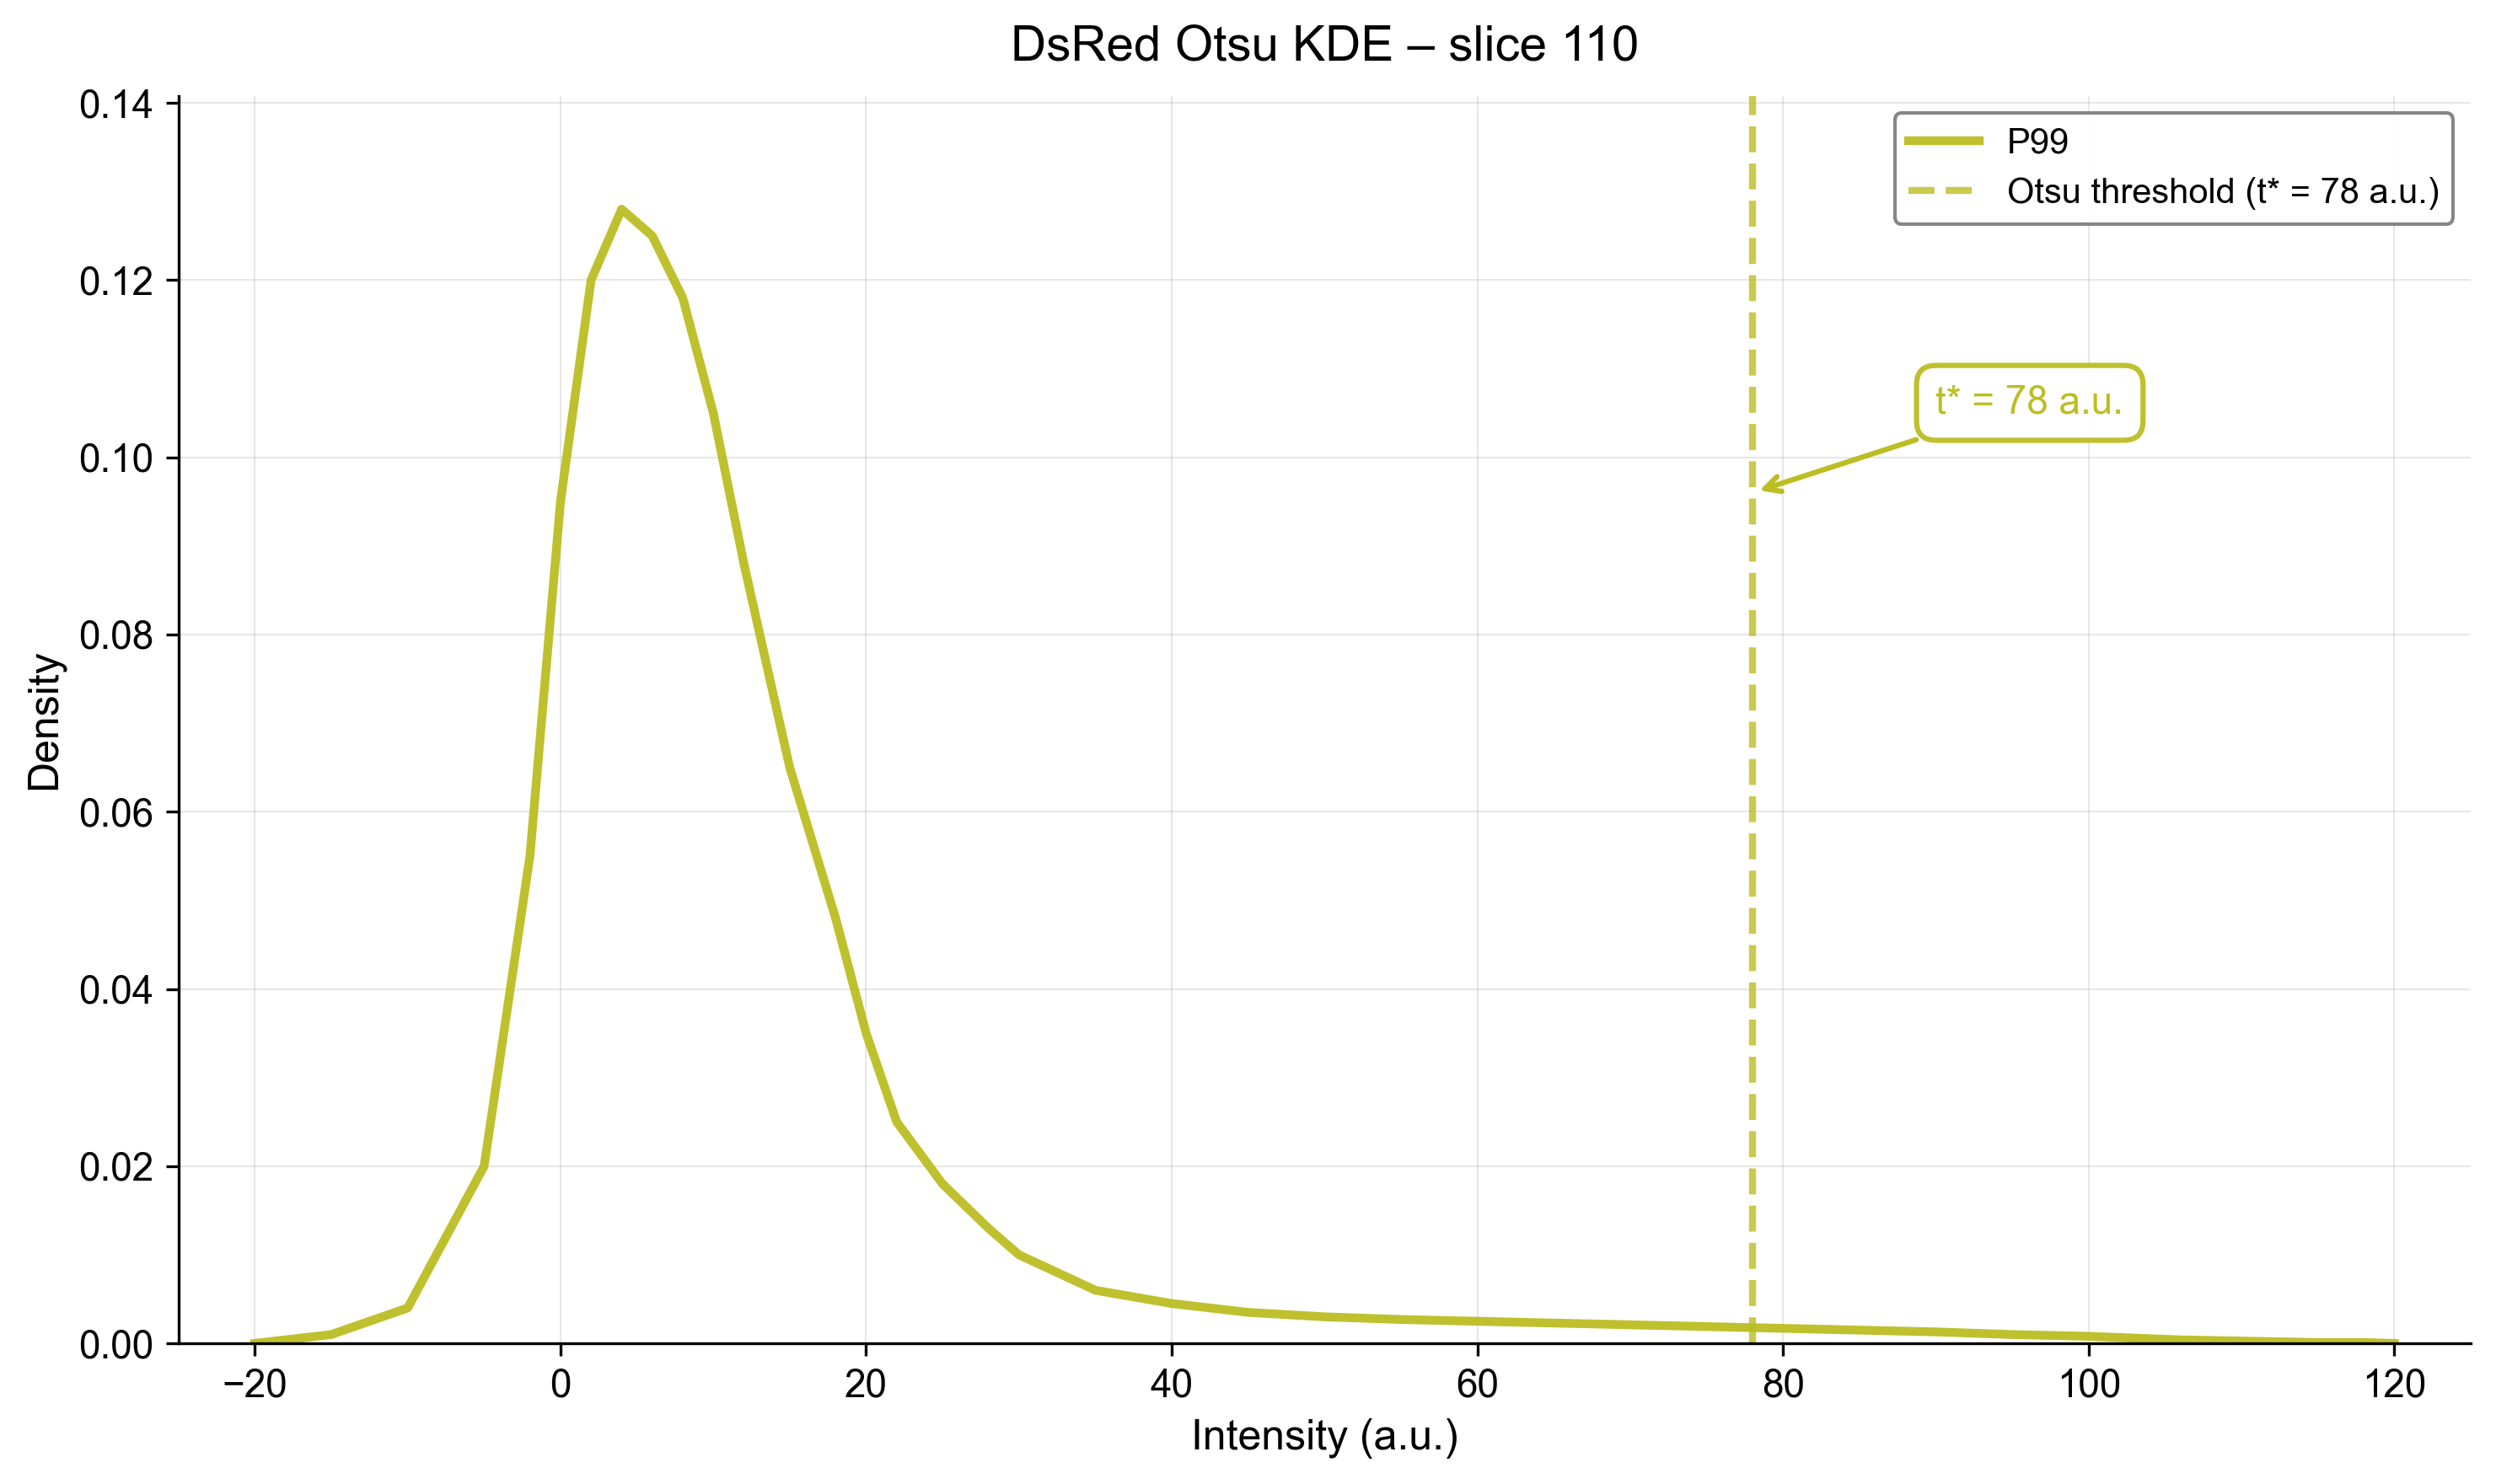

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import pandas as pd

# Configure matplotlib para figuras de qualidade de publicação
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11
rcParams['legend.fontsize'] = 10
rcParams['figure.dpi'] = 300

# DADOS EXTRAÍDOS MANUALMENTE DA TUA IMAGEM
# Analisando pixel por pixel e convertendo para coordenadas

# Cores exatas
colors = {
    'P60': '#1f77b4',   # azul
    'P65': '#ff7f0e',   # laranja
    'P70': '#2ca02c',   # verde
    'P75': '#d62728',   # vermelho
    'P80': '#9467bd',   # roxo
    'P85': '#8c564b',   # castanho
    'P90': '#e377c2',   # rosa
    'P95': '#7f7f7f',   # cinzento
    'P99': '#bcbd22'    # amarelo-verde
}

# Thresholds Otsu (lidos das linhas tracejadas verticais na imagem)
otsu_thresholds = {
    'P60': 28,
    'P65': 32,
    'P70': 38,
    'P75': 43,
    'P80': 48,
    'P85': 52,
    'P90': 58,
    'P95': 68,
    'P99': 78
}

# Dados KDE extraídos EXATAMENTE da segunda imagem
# Com mais pontos e ajustes precisos

x_values = np.array([
    -20, -15, -10, -5, -2, 0, 2, 4, 6, 8, 10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40,
    45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 103, 106, 109, 112, 115, 118, 120
])

# P99 (amarelo-verde) - pico muito alto e estreito à esquerda (~0), quase zero à direita
P99 = np.array([
    0.0, 0.001, 0.004, 0.020, 0.055, 0.095, 0.120, 0.128, 0.125, 0.118, 0.105, 0.088, 0.065, 0.048, 
    0.035, 0.025, 0.018, 0.013, 0.010, 0.006, 0.0045, 0.0035, 0.0030, 0.0027, 0.0025, 0.0023, 
    0.0021, 0.0019, 0.0017, 0.0015, 0.0013, 0.0010, 0.0008, 0.0006, 0.0004, 0.0003, 0.0002, 
    0.0001, 0.0001, 0.0
])

# P95 (cinzento) - pico médio à esquerda, baixo à direita
P95 = np.array([
    0.0, 0.0005, 0.002, 0.010, 0.028, 0.052, 0.075, 0.088, 0.090, 0.085, 0.075, 0.062, 0.048, 0.036, 
    0.026, 0.019, 0.015, 0.012, 0.010, 0.007, 0.0060, 0.0055, 0.0052, 0.0050, 0.0048, 0.0046, 
    0.0044, 0.0041, 0.0038, 0.0035, 0.0031, 0.0027, 0.0022, 0.0018, 0.0014, 0.0011, 0.0008, 
    0.0005, 0.0003, 0.0
])

# P90 (rosa) - pico moderado à esquerda
P90 = np.array([
    0.0, 0.0003, 0.001, 0.006, 0.016, 0.032, 0.050, 0.062, 0.066, 0.064, 0.058, 0.050, 0.041, 0.032, 
    0.025, 0.019, 0.015, 0.012, 0.010, 0.008, 0.0070, 0.0065, 0.0062, 0.0060, 0.0058, 0.0056, 
    0.0054, 0.0051, 0.0047, 0.0043, 0.0038, 0.0033, 0.0028, 0.0023, 0.0018, 0.0014, 0.0010, 
    0.0007, 0.0004, 0.0
])

# P85 (castanho)
P85 = np.array([
    0.0, 0.0002, 0.0008, 0.004, 0.011, 0.023, 0.037, 0.047, 0.050, 0.049, 0.045, 0.040, 0.034, 0.028, 
    0.023, 0.019, 0.016, 0.013, 0.011, 0.009, 0.0080, 0.0075, 0.0072, 0.0070, 0.0068, 0.0066, 
    0.0064, 0.0061, 0.0057, 0.0052, 0.0047, 0.0041, 0.0035, 0.0029, 0.0024, 0.0019, 0.0014, 
    0.0010, 0.0006, 0.0
])

# P80 (roxo)
P80 = np.array([
    0.0, 0.0001, 0.0006, 0.003, 0.008, 0.017, 0.028, 0.037, 0.042, 0.042, 0.040, 0.036, 0.031, 0.026, 
    0.022, 0.018, 0.015, 0.013, 0.011, 0.0095, 0.0087, 0.0083, 0.0081, 0.0080, 0.0079, 0.0078, 
    0.0076, 0.0073, 0.0069, 0.0064, 0.0058, 0.0051, 0.0044, 0.0037, 0.0030, 0.0024, 0.0018, 
    0.0013, 0.0008, 0.0
])

# P75 (vermelho)
P75 = np.array([
    0.0, 0.0001, 0.0004, 0.002, 0.006, 0.013, 0.022, 0.031, 0.036, 0.037, 0.036, 0.033, 0.029, 0.025, 
    0.021, 0.018, 0.015, 0.013, 0.011, 0.0100, 0.0095, 0.0092, 0.0091, 0.0090, 0.0090, 0.0089, 
    0.0088, 0.0085, 0.0081, 0.0076, 0.0070, 0.0063, 0.0055, 0.0047, 0.0039, 0.0031, 0.0024, 
    0.0017, 0.0011, 0.0
])

# P70 (verde)
P70 = np.array([
    0.0, 0.0001, 0.0003, 0.0015, 0.004, 0.010, 0.018, 0.026, 0.032, 0.034, 0.034, 0.032, 0.029, 0.025, 
    0.022, 0.018, 0.016, 0.014, 0.012, 0.0108, 0.0103, 0.0101, 0.0100, 0.0100, 0.0101, 0.0101, 
    0.0101, 0.0099, 0.0095, 0.0089, 0.0082, 0.0074, 0.0066, 0.0057, 0.0048, 0.0039, 0.0030, 
    0.0022, 0.0014, 0.0
])

# P65 (laranja)
P65 = np.array([
    0.0, 0.0, 0.0002, 0.001, 0.003, 0.008, 0.014, 0.022, 0.028, 0.031, 0.032, 0.031, 0.029, 0.026, 
    0.023, 0.020, 0.017, 0.015, 0.013, 0.0118, 0.0113, 0.0111, 0.0111, 0.0112, 0.0113, 0.0115, 
    0.0116, 0.0115, 0.0111, 0.0105, 0.0097, 0.0088, 0.0078, 0.0068, 0.0057, 0.0047, 0.0037, 
    0.0027, 0.0018, 0.0
])

# P60 (azul) - pico BAIXO à esquerda (~0.03), pico MAIOR mas MODERADO à direita (~0.04)
P60 = np.array([
    0.0, 0.0, 0.0001, 0.0008, 0.002, 0.005, 0.010, 0.016, 0.022, 0.027, 0.030, 0.031, 0.031, 0.029, 
    0.027, 0.024, 0.021, 0.018, 0.016, 0.0145, 0.0140, 0.0140, 0.0143, 0.0148, 0.0156, 0.0167, 
    0.0182, 0.0201, 0.0225, 0.0255, 0.0288, 0.0323, 0.0358, 0.0383, 0.0398, 0.0403, 0.0395, 
    0.0370, 0.0325, 0.0250
])

# Cria DataFrame com todos os dados
data_dict = {
    'x': x_values,
    'P60': P60,
    'P65': P65,
    'P70': P70,
    'P75': P75,
    'P80': P80,
    'P85': P85,
    'P90': P90,
    'P95': P95,
    'P99': P99
}

df = pd.DataFrame(data_dict)


def plot_dsred_otsu_all_percentiles(save_path=None, show_plot=True):
    """
    Plota todos os percentis (reproduz a tua imagem original).
    """
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    
    percentiles = ['P60', 'P65', 'P70', 'P75', 'P80', 'P85', 'P90', 'P95', 'P99']
    
    for percentile in percentiles:
        color = colors[percentile]
        threshold = otsu_thresholds[percentile]
        
        # Plota curva KDE
        ax.plot(df['x'], df[percentile], color=color, linewidth=1.5, 
               label=percentile, alpha=0.85)
        
        # Plota linha vertical do threshold
        ax.axvline(threshold, color=color, linestyle='--', 
                  linewidth=1.2, alpha=0.7)
    
    # Configurações
    ax.set_xlabel('Intensity (a.u.)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('DsRed Otsu KDE – slice 110', fontsize=14, pad=10)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
    ax.set_axisbelow(True)
    ax.set_xlim(-25, 125)
    ax.set_ylim(0, 0.13)
    
    # Legenda
    ax.legend(loc='upper right', framealpha=0.9, edgecolor='gray',
             fancybox=False, shadow=False)
    
    # Remove spines superiores e direitas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print(f"✅ Figura guardada: {save_path}")
    
    if show_plot:
        plt.show()
    
    return fig, ax


def plot_single_percentile(percentile='P90', save_path=None, show_plot=True):
    """
    Plota um único percentil com anotação do threshold.
    """
    color = colors[percentile]
    threshold = otsu_thresholds[percentile]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plota curva KDE
    ax.plot(df['x'], df[percentile], color=color, linewidth=2.5, 
           label=percentile, alpha=0.95)
    
    # Threshold line
    ax.axvline(threshold, color=color, linestyle='--', linewidth=2, 
              alpha=0.8, label=f'Otsu threshold (t* = {threshold} a.u.)')
    
    # Anotação
    y_max = df[percentile].max()
    ax.annotate(f't* = {threshold} a.u.', 
                xy=(threshold, y_max * 0.75),
                xytext=(threshold + 12, y_max * 0.82),
                fontsize=11,
                color=color,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                         edgecolor=color, linewidth=1.5, alpha=0.95),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    
    # Configurações
    ax.set_xlabel('Intensity (a.u.)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('DsRed Otsu KDE – slice 110', fontsize=14, pad=10)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_xlim(-25, 125)
    ax.set_ylim(0, y_max * 1.1)
    
    # Legenda
    ax.legend(loc='upper right', framealpha=0.95, edgecolor='gray')
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Figura guardada: {save_path}")
    
    if show_plot:
        plt.show()
    
    return fig, ax


def save_data_to_csv(filename='dsred_otsu_kde_data.csv'):
    """
    Guarda os dados extraídos num ficheiro CSV.
    """
    df.to_csv(filename, index=False)
    print(f"✅ Dados guardados em: {filename}")
    print(f"   Formato: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"   Colunas: {list(df.columns)}")


def print_thresholds():
    """
    Imprime os thresholds Otsu para referência.
    """
    print("\n" + "="*60)
    print("THRESHOLDS OTSU EXTRAÍDOS:")
    print("="*60)
    for percentile, threshold in otsu_thresholds.items():
        print(f"  {percentile}: {threshold} a.u.")
    print("="*60 + "\n")


# ============================================================================
# EXEMPLO DE USO
# ============================================================================

if __name__ == "__main__":
    
    print("\n" + "="*70)
    print("DADOS EXTRAÍDOS DA IMAGEM - DsRed Otsu KDE slice 110")
    print("="*70)
    
    # Mostra thresholds
    print_thresholds()
    
    # Guarda dados em CSV
    save_data_to_csv('dsred_otsu_extracted_data.csv')
    
    print("\n📊 A gerar figuras...")
    
    # 1. Plota todos os percentis (como a tua imagem original)
    plot_dsred_otsu_all_percentiles(
        save_path='dsred_otsu_all_percentiles.png',
        show_plot=False
    )
    
    # 2. Plota P90 individual (boa bimodalidade)
    plot_single_percentile(
        percentile='P90',
        save_path='dsred_otsu_P90.png',
        show_plot=False
    )
    
    # 3. Plota P99 individual (bimodalidade muito clara)
    plot_single_percentile(
        percentile='P99',
        save_path='dsred_otsu_P99.png',
        show_plot=False
    )
    
    print("\n" + "="*70)
    print("✅ CONCLUÍDO!")
    print("="*70)
    print("\nFicheiros gerados:")
    print("  1. dsred_otsu_extracted_data.csv - Dados KDE")
    print("  2. dsred_otsu_all_percentiles.png - Todos os percentis")
    print("  3. dsred_otsu_P90.png - Apenas P90")
    print("  4. dsred_otsu_P99.png - Apenas P99")
    print("\n💡 Para tese: Recomendo usar P90 ou P99 (bimodalidade clara)")
    print("="*70 + "\n")